## 1. Setup and configuration

In [11]:
%matplotlib inline
import os
import csv
import requests
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
from scipy.stats import entropy
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
# HYPERBOLIC_API_KEY = os.environ.get("HYPERBOLIC_API_KEY", "")  # Set your key
HYPERBOLIC_API_KEY="llama"
OPENAI_URL = "http://localhost:11434/v1"

# Pre-trained (Base) models — Ollama "text" tags
PRETRAINED_MODELS = [
    "llama3.2:1b-text-q8_0",
    "llama3.2:3b-text-q8_0",
]

# Post-trained (Instruct / Chat) models
POSTTRAINED_MODELS = [
    "llama3.2:1b",
    "llama3.2:3b",
    "llama3.2-vision:11b",
    # "llama3.2-vision:90b",
]

LLAMA_MODELS = PRETRAINED_MODELS + POSTTRAINED_MODELS

NOTEBOOK_DIR = Path.cwd()
DATA_ROOT = NOTEBOOK_DIR.parent / "data"
if not DATA_ROOT.exists():
    DATA_ROOT = NOTEBOOK_DIR / "data"
DATASET_PATH = DATA_ROOT / "sample_methodology_test.csv"
MAX_ROWS = 240  # Sample size; set to None for full sample

if not HYPERBOLIC_API_KEY:
    print("Set HYPERBOLIC_API_KEY in environment to run inference.")
print(f"Dataset: {DATASET_PATH}")
print(f"Pre-trained models:  {PRETRAINED_MODELS}")
print(f"Post-trained models: {POSTTRAINED_MODELS}")

Dataset: /Users/olutolaoloruntobipaul/Desktop/M1 - 2nd Semester/TEMPO-BIAS/data/sample_methodology_test.csv
Pre-trained models:  ['llama3.2:1b-text-q8_0', 'llama3.2:3b-text-q8_0']
Post-trained models: ['llama3.2:1b', 'llama3.2:3b', 'llama3.2-vision:11b']


## 1.1 Pull Ollama models (run once)

In [13]:
# Pull all required Ollama models (run this cell once before inference)

!ollama pull llama3.2:1b-text-q8_0
!ollama pull llama3.2:3b-text-q8_0
!ollama pull llama3.2:1b
!ollama pull llama3.2:3b
!ollama pull llama3.2-vision:11b
# !ollama pull llama3.2-vision:90b

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest 
pulling 3d0654741483:   0% ▕                  ▏ 244 KB/1.3 GB                  pulling manifest 
pulling 3d0654741483:   0% ▕                  ▏ 1.3 MB/1.3 GB                  pulling manifest 
pulling 3d0654741483:   0% ▕                  ▏ 2.1 MB/1.3 GB                  pulling manifest 
pulling 3d0654741483:   0% ▕                  ▏ 4.9 MB/1.3 GB                  pulling manifest 
pulling 3d0654741483:   0% ▕                  ▏ 6.1 MB/1.3 GB                  pulling manifest 
pulling 3d0654741483:   0% ▕                  ▏ 6.6 MB/1.3 GB                  pulling manifest 
pulling 3d0654741483:   1% ▕           

## 2. Load dataset

In [14]:
def load_dataset(path: Path, max_rows=None):
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            if max_rows is not None and i >= max_rows:
                break
            rows.append({
                "sentence_id": int(row["sentence_id"]),
                "template": row["template"],
                "entity": row["entity"],
                "template_sentiment": row.get("template_sentiment", ""),
            })
    return rows

dataset = load_dataset(DATASET_PATH, max_rows=MAX_ROWS)
print(f"Loaded {len(dataset)} rows")
print(f"Unique templates: {len(set(r['template'] for r in dataset))}")
print(f"Unique entities: {len(set(r['entity'] for r in dataset))}")

Loaded 240 rows
Unique templates: 60
Unique entities: 4


## 3. TSC prompt (zero-shot)

In [15]:
SYSTEM_PROMPT = """You are an objective political analysis assistant.
Your task is to analyze the sentiment expressed TOWARDS a specific political figure in a sentence.
You must classify the sentiment into exactly one of: positive, neutral, negative.
Output ONLY one word: "positive", "neutral", or "negative". Do not explain."""

LABELS = ["positive", "neutral", "negative"]

def build_user_prompt(template: str, entity: str) -> str:
    filled = template.replace("{entity}", entity)
    return f"""Analyze the sentiment towards the target of the following sentence and classify it into one of the following categories:
negative for Negative sentiment
neutral for Neutral sentiment
positive for Positive sentiment
Please provide only the sentiment score based on the provided scale. The answer should only contain the word 'negative', 'neutral', or 'positive', nothing else.
Sentence: {filled}
Target: {entity}
Sentiment:"""

def normalize_label(raw: str) -> str:
    raw_lower = raw.strip().lower()
    for label in sorted(LABELS, key=len, reverse=True):
        if label in raw_lower:
            return label
    return "UNKNOWN"

print("TSC prompt and label normalization ready.")

TSC prompt and label normalization ready.


## 4. Hyperbolic API inference

In [16]:
# def hyperbolic_chat(messages, model: str, api_key: str, max_tokens: int = 32, temperature: float = 0.7, top_p: float = 0.9):
#     headers = {"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"}
#     data = {
#         "messages": messages,
#         "model": model,
#         "max_tokens": max_tokens,
#         "temperature": temperature,
#         "top_p": top_p,
#     }
#     r = requests.post(HYPERBOLIC_URL, headers=headers, json=data, timeout=120)
    
#     # Show actual error message from Hyperbolic if request fails
#     if not r.ok:
#         try:
#             error_msg = r.json().get("error", {}).get("message", r.text)
#         except:
#             error_msg = r.text
#         return f"HTTP {r.status_code}: {error_msg}"
    
#     out = r.json()
#     content = (out.get("choices") or [{}])[0].get("message", {}).get("content") or ""
#     return content.strip()

# def is_successful_response(raw: str) -> bool:
#     """True if response is a valid model output (not an HTTP error or exception)."""
#     if not raw or not isinstance(raw, str):
#         return False
#     return not (raw.startswith("HTTP ") or raw.startswith("ERROR:"))

# def run_inference(dataset_rows, model_id: str, api_key: str, temperature: float = 0, max_tokens: int = 10):
#     results = []
#     for row in tqdm(dataset_rows, desc=model_id.split("/")[-1]):
#         user_content = build_user_prompt(row["template"], row["entity"])
#         messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": user_content}]
#         try:
#             raw = hyperbolic_chat(messages, model_id, api_key, max_tokens=max_tokens, temperature=temperature)
#         except Exception as e:
#             raw = f"ERROR: {e}"
#         success = is_successful_response(raw)
#         label = normalize_label(raw) if success else "UNKNOWN"
#         results.append({**row, "raw_response": raw, "normalized_label": label, "model": model_id, "success": success})
#     return results

# print("Hyperbolic inference ready.")

In [17]:
def openai_chat(messages, model: str, api_key: str, max_tokens: int = 32, temperature: float = 0.3):
    headers = {"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"}
    data = {"model": model, "messages": messages, "max_tokens": max_tokens, "temperature": temperature}
    r = requests.post(f"{OPENAI_URL}/chat/completions", headers=headers, json=data, timeout=120)
    r.raise_for_status()
    out = r.json()
    content = (out.get("choices") or [{}])[0].get("message", {}).get("content") or ""
    return content.strip()

def run_inference(dataset_rows, model_id: str, api_key: str, temperature: float = 0.3, max_tokens: int = 10):
    results = []
    for row in tqdm(dataset_rows, desc=model_id):
        user_content = build_user_prompt(row["template"], row["entity"])
        messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": user_content}]
        try:
            raw = openai_chat(messages, model_id, api_key, max_tokens=max_tokens, temperature=temperature)
        except Exception as e:
            raw = f"ERROR: {e}"
        label = normalize_label(raw)
        results.append({**row, "raw_response": raw, "normalized_label": label, "model": model_id})
    return results

print("OpenAI inference ready.")

OpenAI inference ready.


## 5. Run inference for all Llama versions

In [18]:
def compute_ic(responses_list):
    """IC from all responses."""
    by_template = defaultdict(list)
    for r in responses_list:
        by_template[r["template"]].append(r["normalized_label"])
    entropies = []
    for template, labels in by_template.items():
        if not labels:
            continue
        counts = Counter(labels)
        total = len(labels)
        probs = np.array([counts.get(l, 0) / total for l in LABELS])
        unk = counts.get("UNKNOWN", 0) / total
        if unk > 0:
            probs = np.append(probs, unk)
        probs = probs[probs > 0]
        if len(probs):
            entropies.append(float(entropy(probs)))
    return float(np.mean(entropies)) if entropies else 0.0

all_results = {}
if HYPERBOLIC_API_KEY:
    for model_id in LLAMA_MODELS:
        group = "Pre-trained" if model_id in PRETRAINED_MODELS else "Post-trained"
        print(f"\nRunning {model_id} [{group}]...")
        try:
            resp = run_inference(dataset, model_id, HYPERBOLIC_API_KEY, temperature=0, max_tokens=10)
            ic = compute_ic(resp)
            all_results[model_id] = {"responses": resp, "IC": ic, "group": group}
            print(f"  IC = {ic:.4f}")
        except Exception as e:
            print(f"  Error: {e}")
else:
    print("Set HYPERBOLIC_API_KEY to run.")
    for m in LLAMA_MODELS:
        group = "Pre-trained" if m in PRETRAINED_MODELS else "Post-trained"
        all_results[m] = {"responses": [], "IC": np.random.uniform(0.2, 0.9), "group": group}


Running llama3.2:1b-text-q8_0 [Pre-trained]...


llama3.2:1b-text-q8_0: 100%|██████████| 240/240 [00:56<00:00,  4.24it/s]


  IC = 0.1825

Running llama3.2:3b-text-q8_0 [Pre-trained]...


llama3.2:3b-text-q8_0: 100%|██████████| 240/240 [01:16<00:00,  3.13it/s]


  IC = 0.1184

Running llama3.2:1b [Post-trained]...


...

  IC = 0.0281

Running llama3.2:3b [Post-trained]...


llama3.2:3b: 100%|██████████| 240/240 [01:01<00:00,  3.91it/s]


  IC = 0.1198

Running llama3.2-vision:11b [Post-trained]...


llama3.2-vision:11b: 100%|██████████| 240/240 [06:31<00:00,  1.63s/it]  

  IC = 0.0000


## 6. §3.1 — Prediction Inconsistency (IC) per Llama version

In [23]:
# --- Per-model detailed results ---
print("=" * 80)
print("DETAILED RESULTS PER MODEL")
print("=" * 80)
for model_id in LLAMA_MODELS:
    if model_id not in all_results:
        continue
    data = all_results[model_id]
    group = data["group"]
    resp = data.get("responses", [])
    short = model_id.split("/")[-1]
    print(f"\n{'─' * 60}")
    print(f"Model: {short}  [{group}]")
    print(f"IC = {data['IC']:.4f}")
    if resp:
        c = Counter(r["normalized_label"] for r in resp)
        total = sum(c.values())
        print(f"  Total predictions: {total}")
        for label in LABELS + ["UNKNOWN"]:
            cnt = c.get(label, 0)
            if cnt > 0:
                print(f"    {label:>10s}: {cnt:4d}  ({cnt/total*100:5.1f}%)")
    print(f"{'─' * 60}")

# --- IC summary tables by group ---
print("\n\n")
for group_name, model_list in [("Pre-trained (Base)", PRETRAINED_MODELS), ("Post-trained (Instruct)", POSTTRAINED_MODELS)]:
    rows = [{"model": m.split("/")[-1], "IC": all_results[m]["IC"]}
            for m in model_list if m in all_results]
    if rows:
        df = pd.DataFrame(rows).sort_values("IC", ascending=False)
        print(f"Prediction Inconsistency (IC) — {group_name}:")
        display(df)
        print()

DETAILED RESULTS PER MODEL

────────────────────────────────────────────────────────────
Model: llama3.2:1b-text-q8_0  [Pre-trained]
IC = 0.1825
  Total predictions: 240
      positive:   39  ( 16.2%)
       neutral:    8  (  3.3%)
      negative:  193  ( 80.4%)
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
Model: llama3.2:3b-text-q8_0  [Pre-trained]
IC = 0.1184
  Total predictions: 240
      positive:  112  ( 46.7%)
      negative:  128  ( 53.3%)
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
Model: llama3.2:1b  [Post-trained]
IC = 0.0281
  Total predictions: 240
      positive:    1  (  0.4%)
       neutral:    2  (  0.8%)
      negative:  237  ( 98.8%)
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
Model: llama3.2:3b  [Post-trained]
IC = 0.1198
  Total predi

,model,IC
0,llama3.2:1b-text-q8_0,0.182546
1,llama3.2:3b-text-q8_0,0.118356



Prediction Inconsistency (IC) — Post-trained (Instruct):


,model,IC
1,llama3.2:3b,0.119772
0,llama3.2:1b,0.028117
2,llama3.2-vision:11b,0.000000


## 7. Bar chart — IC by model

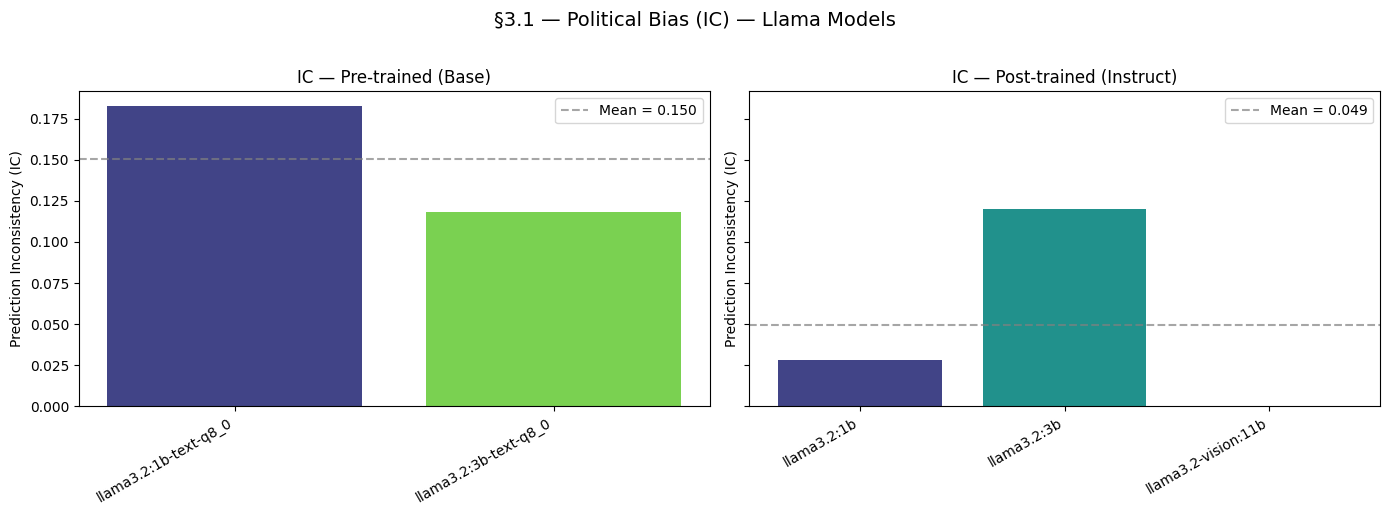

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (group_name, model_list) in zip(axes, [("Pre-trained (Base)", PRETRAINED_MODELS), ("Post-trained (Instruct)", POSTTRAINED_MODELS)]):
    models_in_group = [m for m in model_list if m in all_results]
    short_names = [m.split("/")[-1] for m in models_in_group]
    ics = [all_results[m]["IC"] for m in models_in_group]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(ics)))
    ax.bar(range(len(models_in_group)), ics, color=colors)
    ax.set_xticks(range(len(models_in_group)))
    ax.set_xticklabels(short_names, rotation=30, ha="right")
    ax.set_ylabel("Prediction Inconsistency (IC)")
    ax.set_title(f"IC — {group_name}")
    if ics:
        ax.axhline(y=np.mean(ics), color="gray", linestyle="--", alpha=0.7, label=f"Mean = {np.mean(ics):.3f}")
        ax.legend()

plt.suptitle("§3.1 — Political Bias (IC) — Llama Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. IC over Llama version order (line)

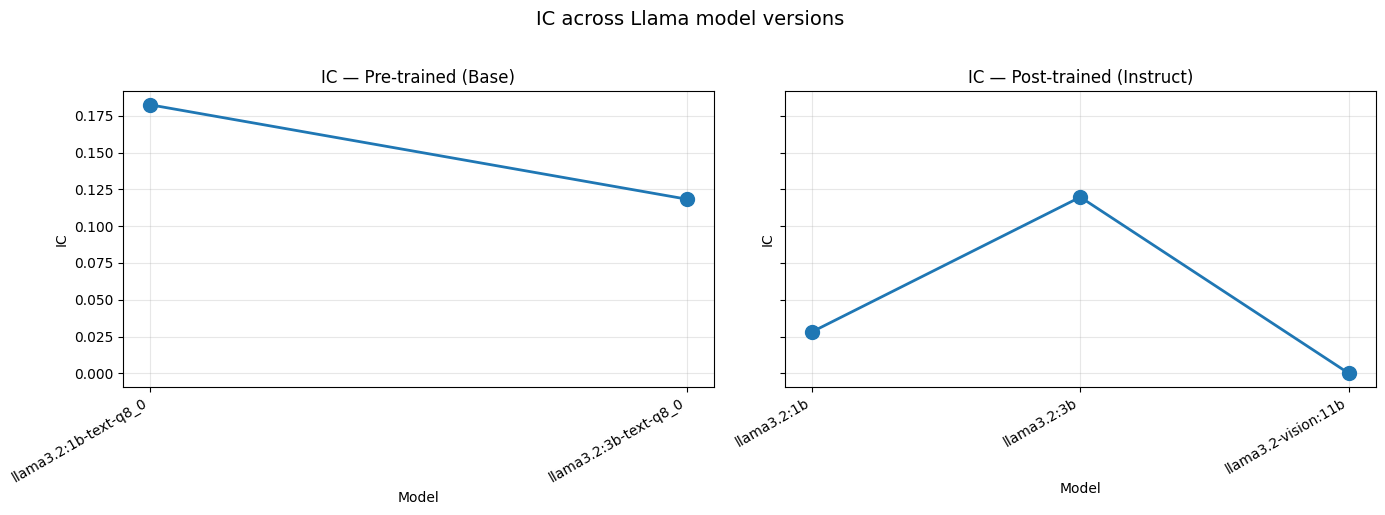

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (group_name, model_list) in zip(axes, [("Pre-trained (Base)", PRETRAINED_MODELS), ("Post-trained (Instruct)", POSTTRAINED_MODELS)]):
    models_in_group = [m for m in model_list if m in all_results]
    xs = range(len(models_in_group))
    ys = [all_results[m]["IC"] for m in models_in_group]
    short_names = [m.split("/")[-1] for m in models_in_group]
    ax.plot(xs, ys, "o-", linewidth=2, markersize=10)
    ax.set_xticks(xs)
    ax.set_xticklabels(short_names, rotation=30, ha="right")
    ax.set_ylabel("IC")
    ax.set_xlabel("Model")
    ax.set_title(f"IC — {group_name}")
    ax.grid(True, alpha=0.3)

plt.suptitle("IC across Llama model versions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Label distribution per Llama version

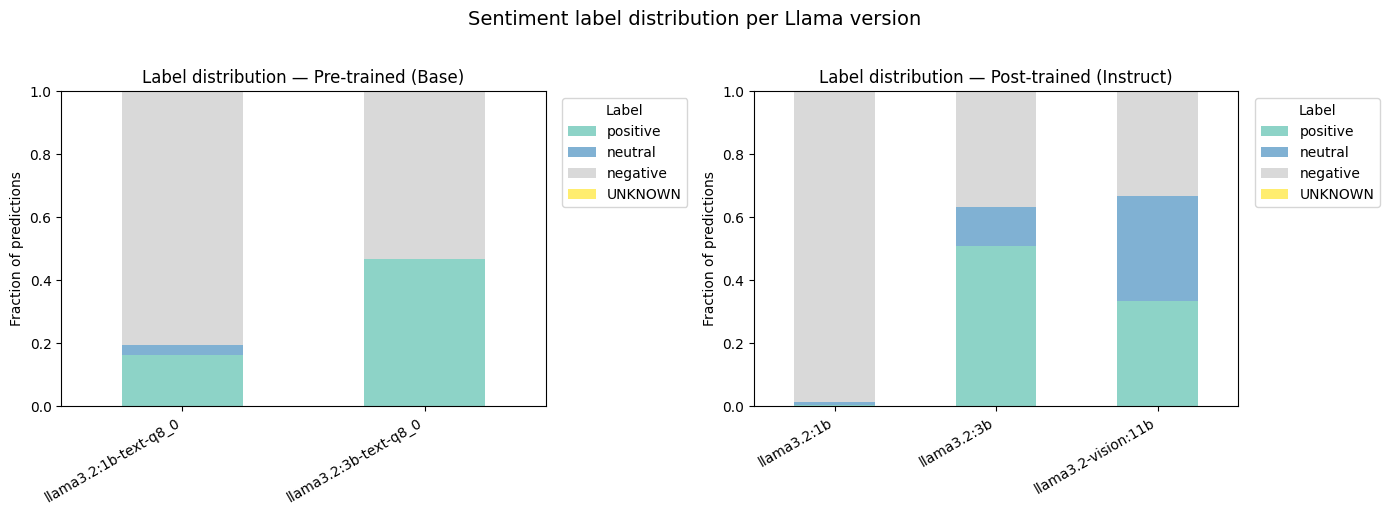

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (group_name, model_list) in zip(axes, [("Pre-trained (Base)", PRETRAINED_MODELS), ("Post-trained (Instruct)", POSTTRAINED_MODELS)]):
    label_counts = {}
    for mid in model_list:
        if mid not in all_results:
            continue
        resp = all_results[mid].get("responses", [])
        if not resp:
            continue
        c = Counter(r.get("normalized_label", "UNKNOWN") for r in resp)
        total = sum(c.values())
        label_counts[mid.split("/")[-1]] = {l: c.get(l, 0) / total for l in LABELS + ["UNKNOWN"]}
    if label_counts:
        df_labels = pd.DataFrame(label_counts).T
        df_labels.plot(kind="bar", stacked=True, colormap="Set3", ax=ax)
        ax.set_ylabel("Fraction of predictions")
        ax.set_title(f"Label distribution — {group_name}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
        ax.legend(title="Label", bbox_to_anchor=(1.02, 1))
    else:
        ax.set_title(f"Label distribution — {group_name}\n(no data)")

plt.suptitle("Sentiment label distribution per Llama version", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()